In [1]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import torchaudio

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import bl_data_load

In [4]:
# setup dataset file path
DATASET_ROOT = r"C:\Users\14362\Desktop\DL\Assignment\Group Project\DL_RIR_AousticAnalysis\dataset"
AUDIO_DIR = os.path.join(DATASET_ROOT, "audio")
LABEL_DIR = os.path.join(DATASET_ROOT, "labels")

TRAIN_DIR = os.path.join(AUDIO_DIR, "train")
VAL_DIR = os.path.join(AUDIO_DIR, "validation")
TEST_DIR = os.path.join(AUDIO_DIR, "test")

TRAIN_CSV = os.path.join(LABEL_DIR, "train_labels_classification_with_ild_itd.csv")
VAL_CSV = os.path.join(LABEL_DIR, "validation_labels_classification_with_ild_itd.csv")
TEST_CSV = os.path.join(LABEL_DIR, "test_labels_classification_with_ild_itd.csv")


In [5]:
# load data and labels
train_X, train_Y = bl_data_load.load_data(TRAIN_DIR, TRAIN_CSV, save_prefix="train")
val_X, val_Y = bl_data_load.load_data(VAL_DIR, VAL_CSV, save_prefix="val")
test_X, test_Y = bl_data_load.load_data(TEST_DIR, TEST_CSV, save_prefix="test")

In [6]:
# input data and labels to torch model
train_loader = bl_data_load.make_pytorch_loader(train_X, train_Y, batch_size=32, shuffle=True)
val_loader = bl_data_load.make_pytorch_loader(val_X, val_Y, batch_size=32, shuffle=False)
test_loader = bl_data_load.make_pytorch_loader(test_X, test_Y, batch_size=32, shuffle=False)

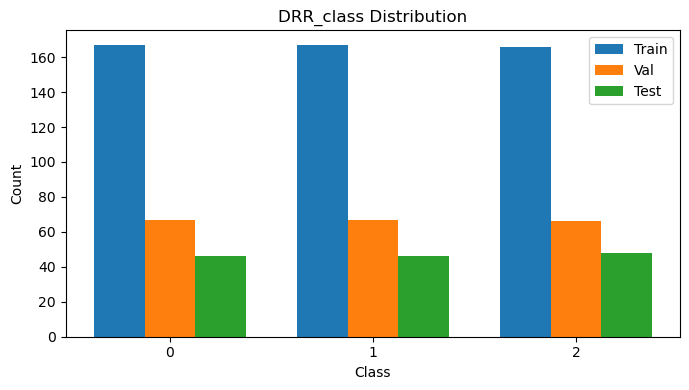

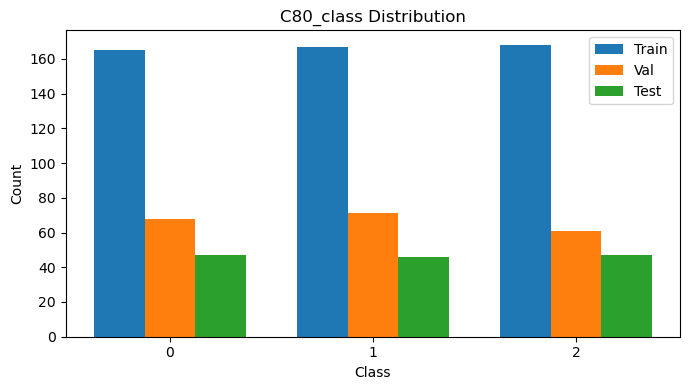

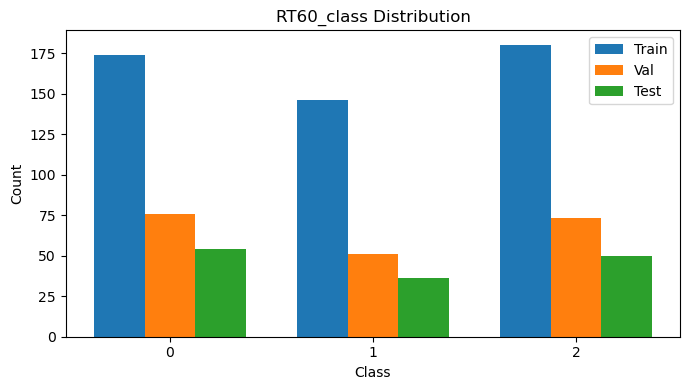

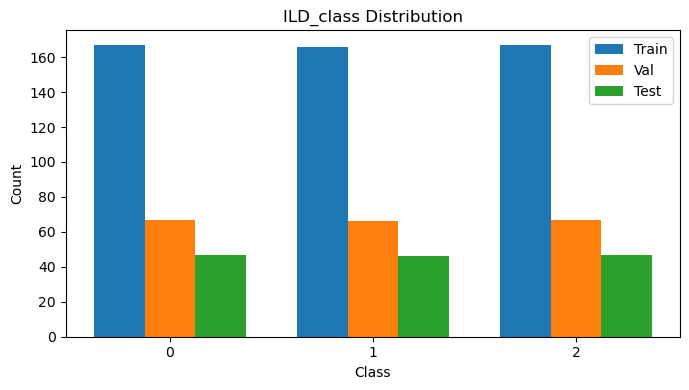

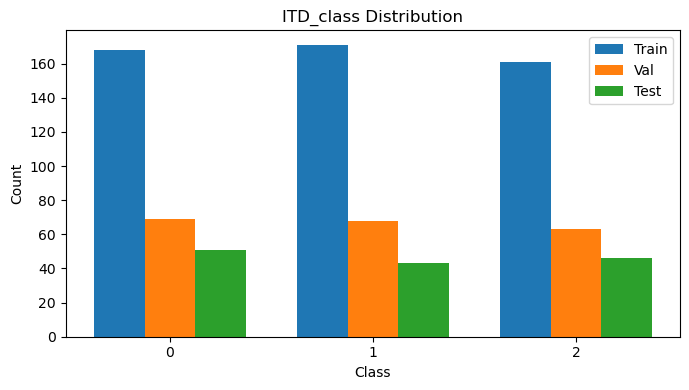

In [7]:
# draw data distribution
label_names = bl_data_load.LABEL_COLUMNS
splits = {
    "Train": train_Y,
    "Val": val_Y,
    "Test": test_Y,
}

for i, name in enumerate(label_names):
    # Collect all possible classes so train/val/test bars align.
    all_classes = sorted(
        set(train_Y[:, i]) | set(val_Y[:, i]) | set(test_Y[:, i])
    )

    def count_per_class(Y, classes):
        return [np.sum(Y[:, i] == c) for c in classes]

    train_counts = count_per_class(train_Y, all_classes)
    val_counts = count_per_class(val_Y, all_classes)
    test_counts = count_per_class(test_Y, all_classes)

    x = np.arange(len(all_classes))
    width = 0.25

    plt.figure(figsize=(7, 4))

    plt.bar(x - width, train_counts, width, label="Train")
    plt.bar(x, val_counts, width, label="Val")
    plt.bar(x + width, test_counts, width, label="Test")

    plt.xticks(x, all_classes)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"{name} Distribution")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [8]:
import bl_model_CNN
import bl_model_core
import bl_model_classification

In [9]:
# build models: frontcnn + conformer + classification_probes
frontcnn = bl_model_CNN.FrontCNN(freq_bins=128, input_dim=144)

conformer = bl_model_core.Conformer(
    input_dim=144,
    num_heads=4,
    ffn_dim=1024,
    num_layers=12,
    depthwise_conv_kernel_size=31,
    dropout=0.1,
)

baseline_model = bl_model_classification.RIRConformerClassifier(
    frontcnn=frontcnn,
    conformer=conformer,
    input_dim=144,
    hidden_dim=72,
    num_classes=3,
)


In [10]:
# train frontcnn and probes with conformer frozen
best_baseline_model =  bl_model_classification.train_frontCNN_probes(
    baseline_model,
    train_loader,
    val_loader,
    epochs=60,
    lr=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

Epoch 1/60 | train loss: 1.10 | train acc: 0.35
                 DRR loss/acc: 1.11/0.30 | C80 loss/acc: 1.10/0.34 | RT60 loss/acc: 1.09/0.42 | ILD loss/acc: 1.10/0.35 | ITD loss/acc: 1.11/0.34
                 val loss: 1.09 | val acc: 0.39
                 DRR loss/acc: 1.10/0.34 | C80 loss/acc: 1.10/0.31 | RT60 loss/acc: 1.07/0.61 | ILD loss/acc: 1.10/0.34 | ITD loss/acc: 1.10/0.34
                 new best model saved at epoch 1
Epoch 2/60 | train loss: 1.10 | train acc: 0.36
                 DRR loss/acc: 1.10/0.33 | C80 loss/acc: 1.09/0.37 | RT60 loss/acc: 1.08/0.46 | ILD loss/acc: 1.10/0.33 | ITD loss/acc: 1.10/0.30
                 val loss: 1.09 | val acc: 0.35
                 DRR loss/acc: 1.10/0.34 | C80 loss/acc: 1.09/0.35 | RT60 loss/acc: 1.07/0.38 | ILD loss/acc: 1.10/0.33 | ITD loss/acc: 1.10/0.34
                 new best model saved at epoch 2
Epoch 3/60 | train loss: 1.09 | train acc: 0.36
                 DRR loss/acc: 1.10/0.33 | C80 loss/acc: 1.09/0.34 | RT60 loss

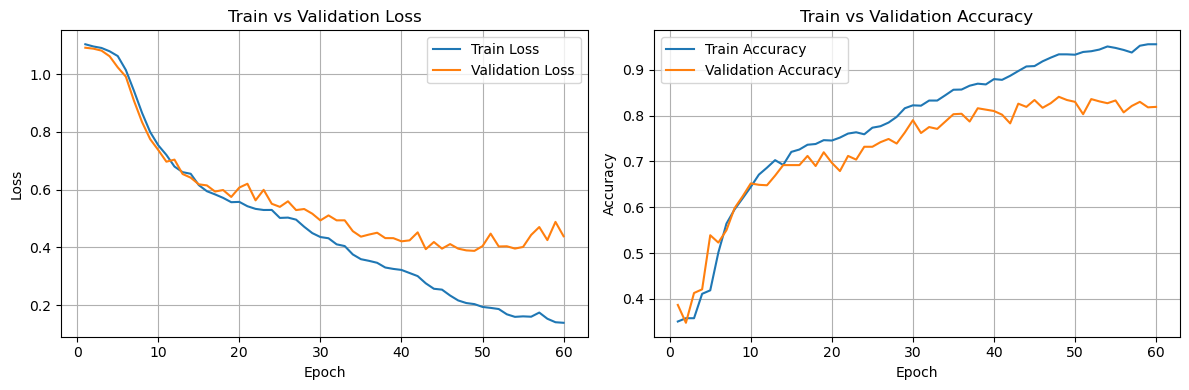

In [11]:
# plot training and validation history
history = best_baseline_model.history
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# predicts test results: loss and acc
bl_model_classification.test_result(best_baseline_model, test_loader)

Test loss: 0.35 | Test acc: 0.85
DRR test loss/acc: 0.29/0.89
C80 test loss/acc: 0.17/0.91
RT60 test loss/acc: 0.10/0.96
ILD test loss/acc: 0.59/0.75
ITD test loss/acc: 0.62/0.71


In [13]:
# extract embeddings before probes
train_embeddings, train_labels = bl_model_classification.extract_embeddings(best_baseline_model, train_loader)
val_embeddings, val_labels = bl_model_classification.extract_embeddings(best_baseline_model, val_loader)
test_embeddings, test_labels = bl_model_classification.extract_embeddings(best_baseline_model, test_loader)

In [14]:
OUT_DIR = r"C:\Users\14362\Desktop\DL\Assignment\Group Project\DL_RIR_AousticAnalysis\baseline_outcome"
os.makedirs(OUT_DIR, exist_ok=True)

np.save(os.path.join(OUT_DIR, "train_embeddings.npy"), train_embeddings)
np.save(os.path.join(OUT_DIR, "train_labels.npy"), train_labels)

np.save(os.path.join(OUT_DIR, "val_embeddings.npy"), val_embeddings)
np.save(os.path.join(OUT_DIR, "val_labels.npy"), val_labels)

np.save(os.path.join(OUT_DIR, "test_embeddings.npy"), test_embeddings)
np.save(os.path.join(OUT_DIR, "test_labels.npy"), test_labels)

print("Saved embeddings and labels to:", OUT_DIR)
print("train:", train_embeddings.shape, train_labels.shape)
print("val:", val_embeddings.shape, val_labels.shape)
print("test:", test_embeddings.shape, test_labels.shape)

Saved embeddings and labels to: C:\Users\14362\Desktop\DL\Assignment\Group Project\DL_RIR_AousticAnalysis\baseline_outcome
train: (500, 144) (500, 5)
val: (200, 144) (200, 5)
test: (140, 144) (140, 5)
